#  LAB ASSIGNMENT 5: LSTM-Based Text Prediction System

| Field | Details |
|---|---|
| **Name** | **PRN**|
| **Sudarshan Khatal** | 202402070016 |
| **Prathamesh Gavhane** | 202402070024|
| **Suraj Konda** | 202402070025 |
|**Gangotari Kompalwar**| 202402070019|
---

| Field | Details |
|---|---|
| **Task** | Text Prediction (Next Word) |
| **Dataset** | Wikipedia REST API |
| **Model** | Bidirectional LSTM |
| **Deployment** | FastAPI |


---
### 🤖 AI Tool Acknowledgement
- **Tool**: Claude (Anthropic)
- **Purpose**: Code structuring, comments, documentation
- **Sections**: Code comments, docstrings, README

##  Step 1: Install Dependencies

In [1]:
!pip install tensorflow numpy pandas matplotlib scikit-learn requests --quiet
print("✅ All libraries installed!")

✅ All libraries installed!


##  Step 2: Import Libraries

In [2]:
import os
import re
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##  Step 3: Dataset Collection — Wikipedia API

We use the **Wikipedia REST API** to automatically collect text from 20+ topics.

**API URL format:** `https://en.wikipedia.org/api/rest_v1/page/summary/{topic}`

In [3]:
import requests

def fetch_wikipedia_text(topics):
    """
    Fetches plain text summaries from Wikipedia for a list of topics.
    Returns combined raw text string from all articles.
    """
    base_url = "https://en.wikipedia.org/api/rest_v1/page/summary/"
    collected = []

    headers = {
        "User-Agent": "AI-Research-Bot/1.0 (student project)"
    }

    for topic in topics:
        try:
            url = base_url + topic.replace(" ", "_")
            response = requests.get(url, headers=headers, timeout=10)

            if response.status_code == 200:
                data = response.json()
                extract = data.get("extract", "")

                if extract:
                    collected.append(extract)
                    print(f"✅ Fetched: {topic} ({len(extract)} chars)")

            else:
                print(f"⚠️ Skipped: {topic} → HTTP {response.status_code}")

        except Exception as e:
            print(f"❌ Error: {topic}: {e}")

    return " ".join(collected)


# Topics: Science, Technology, History
TOPICS = [
    "Artificial intelligence", "Machine learning", "Deep learning",
    "Neural network", "Natural language processing",
    "Computer science", "Python (programming language)",
    "Data science", "Robotics", "Space exploration",
    "Quantum computing", "Internet of things",
    "Blockchain", "Cybersecurity", "Cloud computing",
    "Albert Einstein", "Isaac Newton", "Charles Darwin",
    "Marie Curie", "Alan Turing",
]

print("Fetching data from Wikipedia API...\n")
raw_text = fetch_wikipedia_text(TOPICS)

print("\n" + "="*50)
print(f"Total characters: {len(raw_text):,}")
print(f"Total words (approx): {len(raw_text.split()):,}")

print("\nSample text (first 300 chars):")
print(raw_text[:300])

Fetching data from Wikipedia API...

✅ Fetched: Artificial intelligence (492 chars)
✅ Fetched: Machine learning (483 chars)
✅ Fetched: Deep learning (464 chars)
✅ Fetched: Neural network (668 chars)
✅ Fetched: Natural language processing (321 chars)
✅ Fetched: Computer science (236 chars)
✅ Fetched: Python (programming language) (388 chars)
✅ Fetched: Data science (271 chars)
✅ Fetched: Robotics (292 chars)
✅ Fetched: Space exploration (126 chars)
✅ Fetched: Quantum computing (547 chars)
✅ Fetched: Internet of things (542 chars)
✅ Fetched: Blockchain (633 chars)
✅ Fetched: Cybersecurity (335 chars)
✅ Fetched: Cloud computing (308 chars)
✅ Fetched: Albert Einstein (464 chars)
✅ Fetched: Isaac Newton (738 chars)
✅ Fetched: Charles Darwin (718 chars)
✅ Fetched: Marie Curie (491 chars)
✅ Fetched: Alan Turing (448 chars)

Total characters: 8,984
Total words (approx): 1,277

Sample text (first 300 chars):
Artificial intelligence (AI) is the capability of computational systems to perform task

##  Step 4: Data Preprocessing

**Preprocessing steps:**
1. Lowercase all text
2. Remove URLs and citation markers like `[1]`, `[2]`
3. Remove non-alphabetic characters
4. Collapse multiple spaces

In [4]:
def clean_text(text):
    """
    Cleans raw text for LSTM training.
    """
    text = text.lower()                          # Lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # Remove URLs
    text = re.sub(r"\[\d+\]", "", text)         # Remove citations [1],[2]
    text = re.sub(r"[^a-z\s]", "", text)        # Keep letters only
    text = re.sub(r"\s+", " ", text).strip()    # Collapse spaces
    return text


cleaned_text = clean_text(raw_text)
words = cleaned_text.split()

print(f"Cleaned word count : {len(words):,}")
print(f"Unique words       : {len(set(words)):,}")
print(f"\nCleaned sample     : {cleaned_text[:200]}")

# Top 15 most frequent words
word_freq = Counter(words)
print(f"\n Top 15 Frequent Words:")
for word, count in word_freq.most_common(15):
    bar = "█" * int(count / max(word_freq.values()) * 30)
    print(f"  {word:<20} {count:>5}  {bar}")

Cleaned word count : 1,271
Unique words       : 561

Cleaned sample     : artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problemsolving perception and decisionmak

 Top 15 Frequent Words:
  and                     54  ██████████████████████████████
  the                     53  █████████████████████████████
  of                      45  █████████████████████████
  a                       44  ████████████████████████
  to                      33  ██████████████████
  in                      28  ███████████████
  is                      26  ██████████████
  computer                18  ██████████
  that                    16  ████████
  with                    14  ███████
  for                     12  ██████
  learning                10  █████
  or                      10  █████
  as                       9  █████
  science                  9  █████


##  Step 5: Tokenization & Sequence Generation

**Tokenization**: Converts each word → unique integer ID

**Sequence Generation**: Creates overlapping windows:
- **Input X**: 10 words (context)
- **Output y**: 11th word (target to predict)

In [5]:
# ── Hyperparameters ──────────────────────────
MAX_VOCAB     = 5000   # Top N words in vocabulary
SEQUENCE_LEN  = 10     # Context window (words used to predict next)
EMBEDDING_DIM = 128    # Word vector dimensions
LSTM_UNITS    = 256    # LSTM hidden units
BATCH_SIZE    = 64
EPOCHS        = 30

# ── Tokenizer ────────────────────────────────
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts([cleaned_text])

word_index = tokenizer.word_index
vocab_size = min(MAX_VOCAB, len(word_index)) + 1

print(f"Vocabulary size (capped): {vocab_size}")
print(f"Total unique tokens     : {len(word_index)}")

# Show sample token mappings
sample_words = ["artificial", "intelligence", "learning", "neural", "network"]
print(f"\nSample Token Mappings:")
for w in sample_words:
    idx = tokenizer.word_index.get(w, 'NOT FOUND')
    print(f"  '{w}' → {idx}")

Vocabulary size (capped): 563
Total unique tokens     : 562

Sample Token Mappings:
  'artificial' → 20
  'intelligence' → 31
  'learning' → 13
  'neural' → 26
  'network' → 22


In [6]:
def generate_sequences(text, tokenizer, seq_len):
    """
    Creates overlapping input-output sequence pairs.
    X: seq_len words (input context)
    y: next word (target label, one-hot encoded)
    """
    token_list = tokenizer.texts_to_sequences([text])[0]
    X_seqs, y_labels = [], []

    for i in range(seq_len, len(token_list)):
        context = token_list[i - seq_len : i]  # 10 input words
        target  = token_list[i]                # 1 target word
        X_seqs.append(context)
        y_labels.append(target)

    X = np.array(X_seqs)
    y = tf.keras.utils.to_categorical(y_labels, num_classes=vocab_size)
    return X, y


X, y = generate_sequences(cleaned_text, tokenizer, SEQUENCE_LEN)

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

print(f"Total sequences : {len(X):,}")
print(f"X shape         : {X.shape}  → (samples, sequence_length)")
print(f"y shape         : {y.shape}  → (samples, vocab_size)")
print(f"\nTrain samples   : {len(X_train):,}")
print(f"Val samples     : {len(X_val):,}")

# Show one example
index_word = {v: k for k, v in tokenizer.word_index.items()}
print(f"\nExample sequence:")
print(f"  Input  : {[index_word.get(i, '?') for i in X[0]]}")
print(f"  Target : '{index_word.get(np.argmax(y[0]), '?')}' (one-hot encoded)")

Total sequences : 1,261
X shape         : (1261, 10)  → (samples, sequence_length)
y shape         : (1261, 563)  → (samples, vocab_size)

Train samples   : 1,071
Val samples     : 190

Example sequence:
  Input  : ['artificial', 'intelligence', 'ai', 'is', 'the', 'capability', 'of', 'computational', 'systems', 'to']
  Target : 'perform' (one-hot encoded)


##  Step 6: LSTM Model — Architecture & Math

### Mathematical Equations (for Presentation)

At each time-step **t**:

| Gate | Formula | Purpose |
|---|---|---|
| **Forget** | `fₜ = σ(Wf·[h_{t-1},xₜ]+bf)` | What to discard from memory |
| **Input** | `iₜ = σ(Wi·[h_{t-1},xₜ]+bi)` | What new info to store |
| **Candidate** | `C̃ₜ = tanh(Wc·[h_{t-1},xₜ]+bc)` | Draft new memory values |
| **Cell State** | `Cₜ = fₜ⊙Cₜ₋₁ + iₜ⊙C̃ₜ` | Long-term memory update |
| **Output** | `oₜ = σ(Wo·[h_{t-1},xₜ]+bo)` | What to expose from memory |
| **Hidden** | `hₜ = oₜ⊙tanh(Cₜ)` | Short-term memory + output |
| **Predict** | `ŷ = softmax(Wd·hₜ+bd)` | Word probability distribution |

### Architecture
```
Input (10 words)
     ↓
Embedding Layer (128 dims)
     ↓
Bidirectional LSTM (256 units) ← reads sequence forward & backward
     ↓
Dropout (0.3)
     ↓
LSTM (128 units)
     ↓
Dropout (0.3)
     ↓
Dense (128, ReLU)
     ↓
Dense (vocab_size, Softmax) → probability for each word
```

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Input
import tensorflow as tf

def build_lstm_model(vocab_size, seq_len, embedding_dim, lstm_units):
    """
    Builds Bidirectional LSTM model for next word prediction.
    """
    model = Sequential([
        # Explicit input layer
        Input(shape=(seq_len,)),

        # Embedding layer
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            name="embedding"
        ),

        # Bidirectional LSTM
        Bidirectional(
            LSTM(lstm_units, return_sequences=True),
            name="bi_lstm"
        ),
        Dropout(0.3, name="dropout_1"),

        # Second LSTM
        LSTM(lstm_units // 2, name="lstm_2"),
        Dropout(0.3, name="dropout_2"),

        # Dense layer
        Dense(128, activation="relu", name="dense_hidden"),

        # Output layer
        Dense(vocab_size, activation="softmax", name="output")
    ])

    model.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )

    return model


model = build_lstm_model(vocab_size, SEQUENCE_LEN, EMBEDDING_DIM, LSTM_UNITS)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 128)        │        72,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm (Bidirectional)         │ (None, 10, 512)        │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 563)            │        72,627 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,277,875 (4.87 MB)

 Trainable params: 1,277,875 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

##  Step 7: Train the Model

In [9]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_lstm_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

print("Starting training...\n")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"Best val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss     : {min(history.history['val_loss']):.4f}")

Starting training...

Epoch 1/30
15/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0168 - loss: 6.3277
Epoch 1: val_accuracy improved from None to 0.04737, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.0289 - loss: 6.3036 - val_accuracy: 0.0474 - val_loss: 6.0545 - learning_rate: 0.0010
Epoch 2/30
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0410 - loss: 5.8848
Epoch 2: val_accuracy improved from 0.04737 to 0.05263, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.0345 - loss: 5.8918 - val_accuracy: 0.0526 - val_loss: 5.9467 - learning_rate: 0.0010
Epoch 3/30
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0258 - loss: 5.7211
Epoch 3: val_accuracy did not improve from 0.05263
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0299 - loss: 5.7069 - val_accuracy: 0.

##  Step 8: Plot Training History

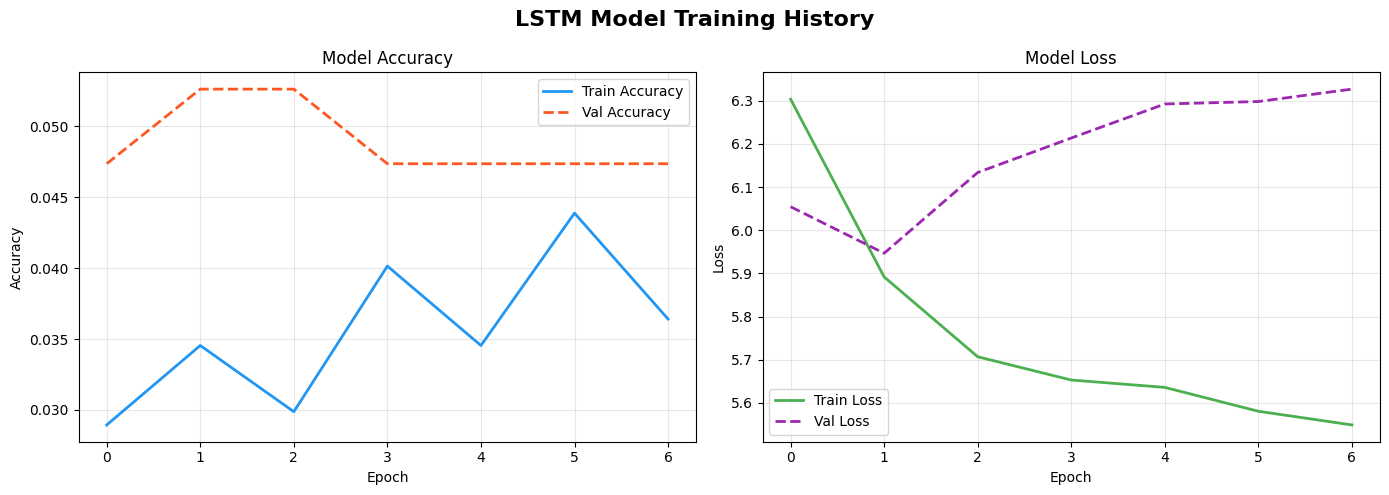

📸 Plot saved as training_history.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM Model Training History", fontsize=16, fontweight="bold")

# Accuracy
axes[0].plot(history.history["accuracy"],     label="Train Accuracy", color="#2196F3", lw=2)
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy",   color="#FF5722", lw=2, ls="--")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss", color="#4CAF50", lw=2)
axes[1].plot(history.history["val_loss"], label="Val Loss",   color="#9C27B0", lw=2, ls="--")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 Plot saved as training_history.png")

##  Step 9: Make Predictions

In [11]:
def predict_next_word(seed_text, tokenizer, model, seq_len, top_k=5):
    """
    Predicts top-k next words for a given seed text.

    Steps:
    1. Tokenize seed text → integer IDs
    2. Pad to seq_len
    3. Forward pass → softmax probabilities
    4. Return top-k words with confidence
    """
    token_list = tokenizer.texts_to_sequences([seed_text.lower()])[0]
    token_list = pad_sequences([token_list], maxlen=seq_len, padding="pre", truncating="pre")

    predictions = model.predict(token_list, verbose=0)[0]
    top_indices = np.argsort(predictions)[::-1][:top_k]

    index_word = {v: k for k, v in tokenizer.word_index.items()}
    return [(index_word.get(int(i), "<OOV>"), float(predictions[i])) for i in top_indices]


def generate_sentence(seed_text, tokenizer, model, seq_len, num_words=10, temperature=0.8):
    """
    Generates a sentence using temperature sampling.
    temperature < 1.0 → deterministic
    temperature > 1.0 → creative/random
    """
    generated = seed_text.lower()
    index_word = {v: k for k, v in tokenizer.word_index.items()}

    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([generated])[0]
        token_list = pad_sequences([token_list], maxlen=seq_len, padding="pre", truncating="pre")

        predictions = model.predict(token_list, verbose=0)[0].astype("float64")

        # Temperature scaling
        predictions = np.log(predictions + 1e-10) / temperature
        predictions = np.exp(predictions)
        predictions = predictions / predictions.sum()

        next_idx  = np.random.choice(len(predictions), p=predictions)
        next_word = index_word.get(int(next_idx), "")
        if next_word:
            generated += " " + next_word

    return generated


# ── Run Predictions ──────────────────────────
test_seeds = [
    "artificial intelligence is",
    "machine learning algorithms",
    "deep learning neural",
    "the human brain",
    "quantum computing can",
]

print("=" * 55)
print("TOP-5 NEXT WORD PREDICTIONS")
print("=" * 55)
for seed in test_seeds:
    preds = predict_next_word(seed, tokenizer, model, SEQUENCE_LEN, top_k=5)
    print(f"\n📝 Seed: '{seed}'")
    for rank, (word, prob) in enumerate(preds, 1):
        bar = "█" * int(prob * 40)
        print(f"  {rank}. {word:<20} {prob:.4f}  {bar}")

TOP-5 NEXT WORD PREDICTIONS

📝 Seed: 'artificial intelligence is'
  1. of                   0.0206  
  2. and                  0.0185  
  3. the                  0.0178  
  4. a                    0.0166  
  5. is                   0.0136  

📝 Seed: 'machine learning algorithms'
  1. of                   0.0204  
  2. and                  0.0184  
  3. the                  0.0176  
  4. a                    0.0165  
  5. is                   0.0135  

📝 Seed: 'deep learning neural'
  1. of                   0.0206  
  2. and                  0.0185  
  3. the                  0.0177  
  4. a                    0.0166  
  5. is                   0.0135  

📝 Seed: 'the human brain'
  1. of                   0.0203  
  2. and                  0.0185  
  3. the                  0.0176  
  4. a                    0.0165  
  5. is                   0.0135  

📝 Seed: 'quantum computing can'
  1. of                   0.0204  
  2. and                  0.0185  
  3. the                  0.0177 

In [12]:
print("=" * 55)
print("GENERATED SENTENCES")
print("=" * 55)

for seed in test_seeds[:3]:
    sentence = generate_sentence(seed, tokenizer, model, SEQUENCE_LEN, num_words=12, temperature=0.8)
    print(f"\n🌱 Seed   : '{seed}'")
    print(f"   Output : '{sentence}'")

GENERATED SENTENCES

🌱 Seed   : 'artificial intelligence is'
   Output : 'artificial intelligence is perform suitable prize method an his nobel theory pool plain natural information'

🌱 Seed   : 'machine learning algorithms'
   Output : 'machine learning algorithms to the be with influential transaction be it data mathison skodowska iot'

🌱 Seed   : 'deep learning neural'
   Output : 'deep learning neural scientific of the a mc her his contributed and because and exploits'


##  Step 10: Save Model & Tokenizer

In [13]:
import json
os.makedirs("saved_model", exist_ok=True)

# Save model
model.save("saved_model/lstm_text_model.keras")

# Save tokenizer
tokenizer_json = tokenizer.to_json()
with open("saved_model/tokenizer.json", "w") as f:
    json.dump(tokenizer_json, f)

# Save config
config = {
    "vocab_size":      vocab_size,
    "sequence_length": SEQUENCE_LEN,
    "embedding_dim":   EMBEDDING_DIM,
    "lstm_units":      LSTM_UNITS,
    "max_vocab":       MAX_VOCAB,
}
with open("saved_model/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("✅ Files saved:")
print("   saved_model/lstm_text_model.keras")
print("   saved_model/tokenizer.json")
print("   saved_model/config.json")

✅ Files saved:
   saved_model/lstm_text_model.keras
   saved_model/tokenizer.json
   saved_model/config.json


##  Step 11: Final Evaluation Summary

In [14]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

print("=" * 50)
print("FINAL EVALUATION SUMMARY")
print("=" * 50)
print(f"  Validation Loss     : {val_loss:.4f}")
print(f"  Validation Accuracy : {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Total Parameters    : {model.count_params():,}")
print(f"  Vocabulary Size     : {vocab_size:,}")
print(f"  Sequence Length     : {SEQUENCE_LEN}")
print(f"  Training Samples    : {len(X_train):,}")
print(f"  Validation Samples  : {len(X_val):,}")
print("=" * 50)
print("\n✅ Assignment Complete! Ready for FastAPI deployment.")

FINAL EVALUATION SUMMARY
  Validation Loss     : 5.9467
  Validation Accuracy : 0.0526 (5.26%)
  Total Parameters    : 1,277,875
  Vocabulary Size     : 563
  Sequence Length     : 10
  Training Samples    : 1,071
  Validation Samples  : 190

✅ Assignment Complete! Ready for FastAPI deployment.


##  LSTM Math Reference (For Presentation)

```
╔══════════════════════════════════════════════════╗
║         LSTM MATHEMATICAL MODEL                  ║
╚══════════════════════════════════════════════════╝

Inputs at time t:
  xₜ      → current word embedding
  h_{t-1} → previous hidden state (short-term memory)
  C_{t-1} → previous cell state   (long-term memory)

FORGET GATE   fₜ = σ(Wf · [h_{t-1}, xₜ] + bf)
  → What to DISCARD from old memory. 0=forget, 1=keep

INPUT GATE    iₜ = σ(Wi · [h_{t-1}, xₜ] + bi)
CANDIDATE     C̃ₜ = tanh(Wc · [h_{t-1}, xₜ] + bc)
  → What NEW info to store in memory

CELL STATE    Cₜ = fₜ ⊙ Cₜ₋₁ + iₜ ⊙ C̃ₜ
  → LONG-TERM MEMORY. ⊙ = element-wise multiply
  → Additive update = no vanishing gradient!

OUTPUT GATE   oₜ = σ(Wo · [h_{t-1}, xₜ] + bo)
  → What part of Cₜ to expose as output

HIDDEN STATE  hₜ = oₜ ⊙ tanh(Cₜ)
  → SHORT-TERM MEMORY. Passed to next step

PREDICTION    ŷ = softmax(Wd · hₜ + bd)
  → Probability over all vocabulary words
  → argmax(ŷ) = most likely next word
```